
# Evaluation (TEST)



In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os


plt.style.use("seaborn-v0_8-whitegrid")

palette = {
    "Plastic (own)": "#67be9b",
    "PPO": "#FFAC1C",
    "PPO-curriculum": "#f1db42",
    "transfer": "#678dbe",
    "scratch": "#dd42f1"
}


## 1) Configurar rutas de CSV

In [63]:
path = "data/test/*.csv"

files = glob.glob(path)

dataframes = []

df_all = None

for file in files:
    df = pd.read_csv(file)

    filename = os.path.basename(file)

    print(filename)

    parts = filename.replace(".csv", "").split("_")

    method = parts[2]  # plastic / ppo
    method = method.upper()

    if method == "PLASTIC":
        method = "Plastic (own)"

    scenario = parts[3]  # simple / medium / complex
    type_ = parts[4]  # scratch / transfer

    df["method"] = method
    df["scenario"] = scenario
    df["type"] = type_

    dataframes.append(df)

df_all = pd.concat(dataframes, ignore_index=True)

df_all.head(25)

evaluation_results_plastic_complex_scratch_20260424_161814.csv
evaluation_results_ppo_complex_scratch_20260424_150408.csv
evaluation_results_ppo_medium_scratch_20260424_150408.csv
evaluation_results_plastic_medium_scratch_20260424_161814.csv
evaluation_results_plastic_complex_transfer_20260424_161814.csv
evaluation_results_plastic_medium_transfer_20260424_161814.csv
evaluation_results_ppo_medium_transfer_20260424_150408.csv
evaluation_results_plastic_simple_scratch_20260424_161814.csv
evaluation_results_ppo_complex_transfer_20260424_150408.csv
evaluation_results_ppo_simple_scratch_20260424_150408.csv


,episode,success,episode_reward,steps,final_distance,method,scenario,type
0,0,1,809.606645,862,0.299231,Plastic (own),complex,scratch
1,1,1,754.401202,804,0.299646,Plastic (own),complex,scratch
2,2,1,722.373582,770,0.299226,Plastic (own),complex,scratch
3,3,1,688.336378,734,0.298932,Plastic (own),complex,scratch
4,4,1,663.799968,708,0.298381,Plastic (own),complex,scratch
5,5,1,640.182231,683,0.299045,Plastic (own),complex,scratch
6,6,1,617.494402,659,0.298816,Plastic (own),complex,scratch
7,7,1,598.487550,639,0.298028,Plastic (own),complex,scratch
8,8,1,585.275939,625,0.298971,Plastic (own),complex,scratch
9,9,1,567.806838,607,0.298420,Plastic (own),complex,scratch


## 3) Métricas básicas

In [64]:

metrics = df_all.groupby(["method", "type"]).agg({
    "success": "mean",
    "episode_reward": ["mean", "std"],
    "steps": "mean",
    "final_distance": "mean"
})

metrics.columns = ["success_rate", "reward_mean", "reward_std", "steps_mean", "distance_mean"]
metrics = metrics.reset_index()
metrics


,method,type,success_rate,reward_mean,reward_std,steps_mean,distance_mean
0,PPO,scratch,0.333333,1132.458741,1209.075815,4539.633333,2.442574
1,PPO,transfer,0.000000,2145.918758,1596.706276,3847.000000,2.108305
2,Plastic (own),scratch,1.000000,650.046991,69.876064,689.166667,0.299138
3,Plastic (own),transfer,1.000000,658.657768,73.287862,700.450000,0.299036


## 4) Transfer Ratio (TR)

In [65]:
results_tr = []

for method in df_all["method"].unique():
    for scenario in df_all["scenario"].unique():

        d = df_all[
            (df_all["method"] == method) &
            (df_all["scenario"] == scenario)
        ]

        baseline = d[d["type"] == "scratch"]["episode_reward"].mean()
        transfer = d[d["type"] == "transfer"]["episode_reward"].mean()

        if pd.isna(baseline) or baseline == 0:
            tr = np.nan
        else:
            tr = transfer / baseline

        results_tr.append({
            "method": method,
            "scenario": scenario,
            "TR": tr
        })

df_tr = pd.DataFrame(results_tr)

In [66]:
df_tr

,method,scenario,TR
0,Plastic (own),complex,1.000000
1,Plastic (own),medium,1.000000
2,Plastic (own),simple,NaN
3,PPO,complex,1.631646
4,PPO,medium,1.249998
5,PPO,simple,NaN


## 5) Gráficas

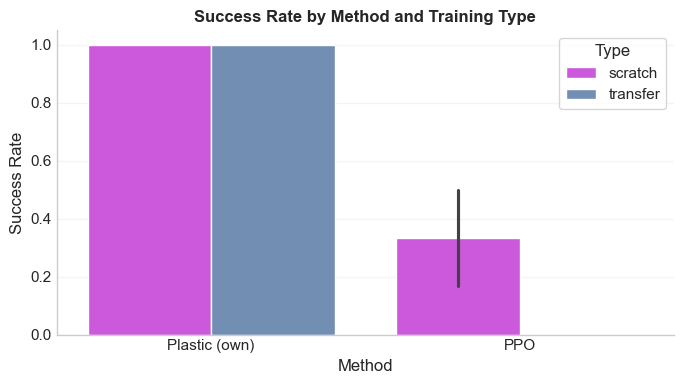

In [67]:
fig, ax = plt.subplots(figsize=(7,4))

sns.barplot(
    data=df_all,
    x="method",
    y="success",
    hue="type",
    estimator=np.mean,
    palette=palette,
    ax=ax
)

ax.set_title("Success Rate by Method and Training Type", fontsize=12, weight='bold')
ax.set_ylabel("Success Rate")
ax.set_xlabel("Method")

ax.grid(axis='y', alpha=0.2)

ax.legend(title="Type", frameon=True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()

fig.savefig(
    "success_rate_evaluation.pdf",
    bbox_inches='tight'
)

plt.show()
plt.close(fig)

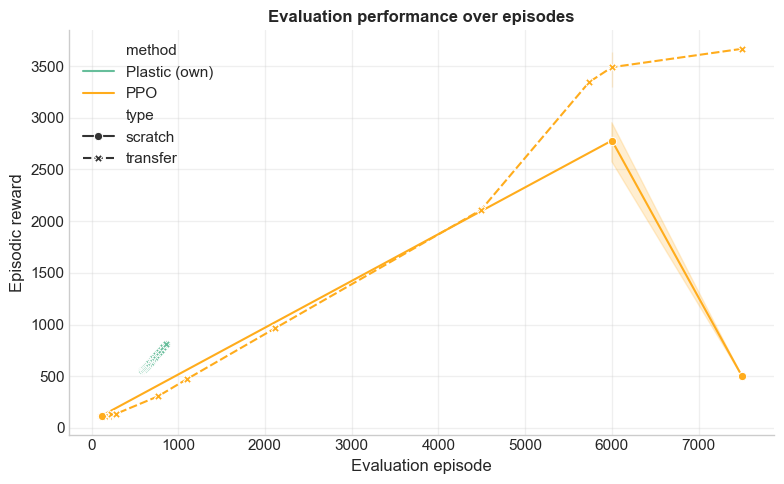

In [75]:
df_all["episode_idx"] = df_all.groupby(["method", "type"]).cumcount()

fig, ax = plt.subplots(figsize=(8,5))

sns.lineplot(
    data=df_all,
    x="steps",
    y="episode_reward",
    hue="method",
    style="type",
    markers=True,
    palette=palette,
    ax=ax
)

# títulos
ax.set_title("Evaluation performance over episodes", fontsize=12, weight='bold')
ax.set_xlabel("Evaluation episode")
ax.set_ylabel("Episodic reward")

# grid suave
ax.grid(alpha=0.3)

# quitar bordes
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# leyenda
# ax.legend(title="Method / Type")

fig.tight_layout()

fig.savefig(
    "evaluation_performance.pdf",
    bbox_inches='tight'
)

plt.show()

# opcional
plt.close(fig)

In [69]:
print(df_all.groupby(["method", "type"]).size())

method         type    
PPO            scratch     30
               transfer    20
Plastic (own)  scratch     30
               transfer    20
dtype: int64


## Tabla resumen

In [70]:

summary = df_all.groupby("method").agg({
    "success": "mean",
    "episode_reward": "mean",
    "steps": "mean"
}).reset_index()

summary.columns = ["Method", "Success Rate", "Final Reward", "Avg Steps"]
summary


,Method,Success Rate,Final Reward,Avg Steps
0,PPO,0.2,1537.842748,4262.58
1,Plastic (own),1.0,653.491302,693.68
